In [1]:
# CARGA DE LAS LIBRERÍAS
import os
import re
import pdfplumber
import spacy

# Bloque 1 - Extracción y Limpieza de Texto

In [2]:
!python -m spacy download es_core_news_sm
nlp = spacy.load("es_core_news_sm")

     ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
     -------------------------- ------------- 8.4/12.9 MB 47.2 MB/s eta 0:00:01
     ---------------------------------------- 12.9/12.9 MB 38.5 MB/s  0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
STOPWORDS_POLITICAS = {
    "proponer", "propuesta", "partido", "programa", "electoral", "españa", "español", 
    "española", "españoles", "ciudadano", "ciudadana", "ciudadanos", "medida", "medidas",
    "hacer", "ir", "año", "años", "gobierno", "política", "políticas", "así", "cada", 'bloque',
    'julio', 'madrid', 'él'
}

def extraer_texto_pdf(ruta_pdf):
    """Extrae todo el texto plano de un archivo PDF."""
    texto_completo = []
    with pdfplumber.open(ruta_pdf) as pdf:
        for pagina in pdf.pages:
            texto_pagina = pagina.extract_text()
            if texto_pagina:
                texto_completo.append(texto_pagina)
    return " ".join(texto_completo)

def limpiar_y_lematizar(texto):
    """Limpia el texto, elimina stopwords generales/políticas y devuelve los lemas."""
    # Limpieza básica: minúsculas y eliminar números/puntuación
    texto = texto.lower()
    texto = re.sub(r'\bimpulsarer\b', 'impulsar', texto)
    texto = re.sub(r'[^\w\s]', ' ', texto)  # Quita signos de puntuación
    texto = re.sub(r'\d+', ' ', texto)      # Quita números
    texto = re.sub(r'\s+', ' ', texto).strip() # Normaliza espacios blancos
    # Procesamiento con spaCy
    doc = nlp(texto)
    
    palabras_limpias = []
    for token in doc:
        # Filtrar si: es stopword de spaCy, es muy corta, o está en nuestra lista política
        if not token.is_stop and len(token.text) > 2:
            lema = token.lemma_
            if lema not in STOPWORDS_POLITICAS:
                palabras_limpias.append(lema)
                
    return " ".join(palabras_limpias)

In [ ]:
#EJECUCIÓN DE LA FUNCION 

programas = {
    "PP": "PP-PG23.pdf",
    "PSOE": "PSOE-PG23.pdf",
    "VOX": "VOX-PG23.pdf",
    "SUMAR": "SUMAR-PG23.pdf"
}

corpus_procesado = {}

for partido, ruta in programas.items():
    if os.path.exists(ruta):
        print(f"Procesando el programa de {partido}...")
        texto_bruto = extraer_texto_pdf(ruta)
        texto_limpio = limpiar_y_lematizar(texto_bruto)
        corpus_procesado[partido] = texto_limpio
        print(f"{partido} procesado. Palabras clave extraídas: {len(texto_limpio.split())}")
    else:
        print(f"Archivo no encontrado para {partido}: {ruta}")

Procesando el programa de PP...
✓ PP procesado. Palabras clave extraídas: 13958
Procesando el programa de PSOE...
✓ PSOE procesado. Palabras clave extraídas: 46465
Procesando el programa de VOX...
✓ VOX procesado. Palabras clave extraídas: 13368
Procesando el programa de SUMAR...
✓ SUMAR procesado. Palabras clave extraídas: 49894


# BLOQUE 2 - Código de Análisis Lineal: TF-IDF con Scikit-Learn 

In [5]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

if corpus_procesado:
    partidos= list(corpus_procesado.keys())
    textos= list(corpus_procesado.values())
    vectorizador= TfidfVectorizer(ngram_range=(1,2), max_features=2000)
    tfidf_matrix= vectorizador.fit_transform(textos)
    nombres_features= vectorizador.get_feature_names_out()
    df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), index=partidos, columns=nombres_features)
    print("TOP 10 PALABRAS POR PARTIDO:")
    for partido in partidos:
        print(f"\n{partido}:")
        palabras = df_tfidf.loc[partido].sort_values(ascending=False).head(10)
        for palabra, valor in palabras.items():
            print(f"  {palabra}: {valor:.4f}")
    else:
        print("No se procesaron programas. Verifique los archivos PDF.")

TOP 10 PALABRAS POR PARTIDO:

PP:
  público: 0.1986
  administración: 0.1697
  objetivo: 0.1620
  social: 0.1600
  impulsarer: 0.1542
  nacional: 0.1523
  ley: 0.1427
  país: 0.1330
  sistema: 0.1311
  servicio: 0.1234

PSOE:
  social: 0.2406
  público: 0.2227
  persona: 0.2069
  mujer: 0.1689
  derecho: 0.1543
  digital: 0.1445
  seguir: 0.1304
  servicio: 0.1276
  país: 0.1276
  sistema: 0.1276

VOX:
  ley: 0.3230
  nacional: 0.2671
  familia: 0.1594
  proposición: 0.1528
  proposición ley: 0.1528
  público: 0.1357
  derecho: 0.1271
  él: 0.1249
  vox: 0.1236
  social: 0.1077

SUMAR:
  público: 0.3000
  persona: 0.2642
  social: 0.2370
  derecho: 0.2007
  servicio: 0.1634
  sistema: 0.1387
  garantizar: 0.1341
  trabajo: 0.1150
  él: 0.1069
  económico: 0.1069
No se procesaron programas. Verifique los archivos PDF.


# BLOQUE 3 - Matriz de Similitud ideológica

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

# 1. Calcular la similitud de coseno entre todos los vectores de la matriz TF-IDF
matriz_similitud = cosine_similarity(tfidf_matrix)

# 2. Convertir la matriz resultante en un DataFrame con etiquetas de filas y columnas
df_similitud = pd.DataFrame(
    matriz_similitud, 
    index=partidos, 
    columns=partidos
)

print("\n=== MATRIZ DE SIMILITUD DE COSENO (DISTANCIA IDEOLÓGICA) ===")
# Formatear la salida para mostrar solo 2 decimales y facilitar la lectura
print(df_similitud.round(4))


=== MATRIZ DE SIMILITUD DE COSENO (DISTANCIA IDEOLÓGICA) ===
           PP    PSOE     VOX   SUMAR
PP     1.0000  0.8515  0.7039  0.8080
PSOE   0.8515  1.0000  0.6364  0.8737
VOX    0.7039  0.6364  1.0000  0.6378
SUMAR  0.8080  0.8737  0.6378  1.0000


# BLOQUE 4 - Visualización

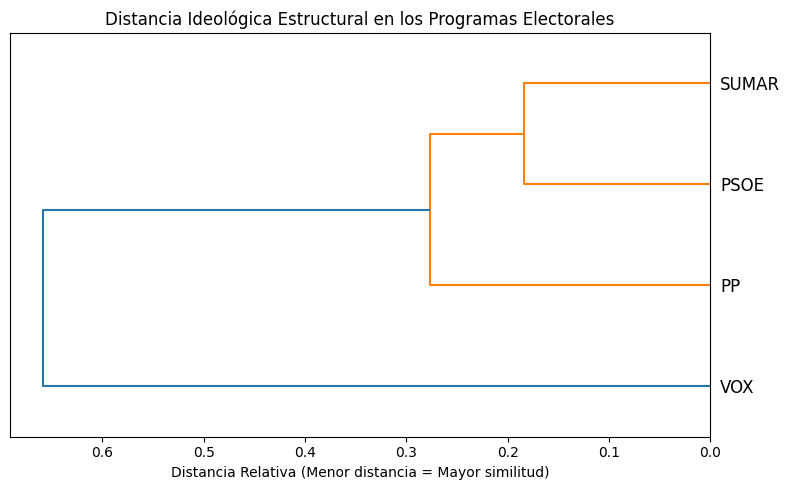

In [7]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

# 1. Convertir la similitud en "distancia" (a mayor similitud, menor distancia)
distancia = 1 - matriz_similitud

# 2. Calcular el enlace jerárquico (Ward minimiza la varianza dentro de los grupos)
enlaces = linkage(distancia, method='ward')

# 3. Configurar y dibujar el gráfico
plt.figure(figsize=(8, 5))
dendrogram(
    enlaces, 
    labels=partidos, 
    orientation='left',  # Orientación horizontal para leer mejor los nombres
    leaf_font_size=12
)

plt.title("Distancia Ideológica Estructural en los Programas Electorales")
plt.xlabel("Distancia Relativa (Menor distancia = Mayor similitud)")
plt.tight_layout()
plt.show()

# BLOQUE 5 - Sentimiento

In [8]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1. Inicializar el analizador de sentimiento
# Nota: VADER está optimizado para inglés, por lo que usaremos los textos originales 
# previos a la eliminación de stopwords si queremos capturar adverbios de negación (ej. "no", "nunca")
analyzer = SentimentIntensityAnalyzer()

print("\n=== ANÁLISIS DE SENTIMIENTO RELEVANTE (POLARIDAD) ===")

resultados_sentimiento = {}

# Es mejor evaluar el texto bruto por oraciones para no perder la estructura del contexto
for partido, ruta in programas.items():
    # Recuperamos el texto bruto extraído en el Bloque 1
    texto_bruto = extraer_texto_pdf(ruta)
    
    # Fragmentar en párrafos o bloques de texto manejables para el analizador
    fragmentos = [f.strip() for f in texto_bruto.split('\n') if len(f.strip()) > 10]
    
    pos_acumulado = 0
    neg_acumulado = 0
    neu_acumulado = 0
    total = len(fragmentos)
    
    for f in fragmentos:
        # VADER procesa internamente la estructura. Nota: Para producción formal se traduciría o usaría un modelo específico en español como 'pysentimiento'
        vs = analyzer.polarity_scores(f)
        pos_acumulado += vs['pos']
        neg_acumulado += vs['neg']
        neu_acumulado += vs['neu']
    
    # Promedios
    resultados_sentimiento[partido] = {
        'Positivo (Propuestas/Avances)': (pos_acumulado / total) * 100,
        'Negativo (Crítica/Denuncia)': (neg_acumulado / total) * 100,
        'Neutral (Técnico/Normativo)': (neu_acumulado / total) * 100
    }

# 2. Mostrar resultados en una tabla comparativa
df_sentimiento = pd.DataFrame(resultados_sentimiento).T
print(df_sentimiento.round(2))


=== ANÁLISIS DE SENTIMIENTO RELEVANTE (POLARIDAD) ===
       Positivo (Propuestas/Avances)  Negativo (Crítica/Denuncia)  \
PP                              0.68                         0.71   
PSOE                            0.74                         0.81   
VOX                             0.73                         1.29   
SUMAR                           0.41                         1.06   

       Neutral (Técnico/Normativo)  
PP                           98.61  
PSOE                         98.45  
VOX                          97.98  
SUMAR                        98.53  


# PARTE 2 - ANÁLISIS DE PROPUESTAS

In [9]:
from sentence_transformers import SentenceTransformer, util
import pandas as pd
import numpy as np
import torch

# 1. Cargar modelo preentrenado (multilingüe, optimizado para similitud)
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

def obtener_propuestas_y_vectores(texto):
    # Segmentación básica por puntos (en producción, usar Spacy para mayor precisión)
    oraciones = [o.strip() for o in texto.split('.') if len(o.split()) > 5]
    vectores = model.encode(oraciones, convert_to_tensor=True)
    return oraciones, vectores

# --- EJECUCIÓN POR PARTIDO ---
datos_semanticos = {}
for partido, texto in corpus_procesado.items():
    oraciones, vectores = obtener_propuestas_y_vectores(texto)
    datos_semanticos[partido] = {'oraciones': oraciones, 'vectores': vectores}

# 2. Comparativa: ¿Cuánto se parecen las propuestas del Partido A frente al Partido B?
def comparar_partidos(p1, p2):
    # Calculamos la matriz de similitud de todas las frases contra todas
    cosine_scores = util.cos_sim(datos_semanticos[p1]['vectores'], datos_semanticos[p2]['vectores'])
    # Promedio de las coincidencias más altas
    coincidencia_promedio = torch.mean(torch.max(cosine_scores, dim=1).values)
    return coincidencia_promedio.item()

# Ejemplo: Comparativa directa
print(f"Similitud semántica entre PP y PSOE: {comparar_partidos('PP', 'PSOE'):.2%}")
print(f"Similitud semántica entre PP y VOX: {comparar_partidos('PP', 'VOX'):.2%}")
print(f"Similitud semántica entre PP y SUMAR: {comparar_partidos('PP', 'SUMAR'):.2%}")
print(f"Similitud semántica entre SUMAR y PSOE: {comparar_partidos('SUMAR', 'PSOE'):.2%}")
print(f"Similitud semántica entre SUMAR y VOX: {comparar_partidos('SUMAR', 'VOX'):.2%}")
print(f"Similitud semántica entre VOX y PSOE: {comparar_partidos('VOX', 'PSOE'):.2%}")


Similitud semántica entre PP y PSOE: 70.30%
Similitud semántica entre PP y VOX: 63.91%
Similitud semántica entre PP y SUMAR: 65.50%
Similitud semántica entre SUMAR y PSOE: 71.36%
Similitud semántica entre SUMAR y VOX: 73.59%
Similitud semántica entre VOX y PSOE: 65.69%


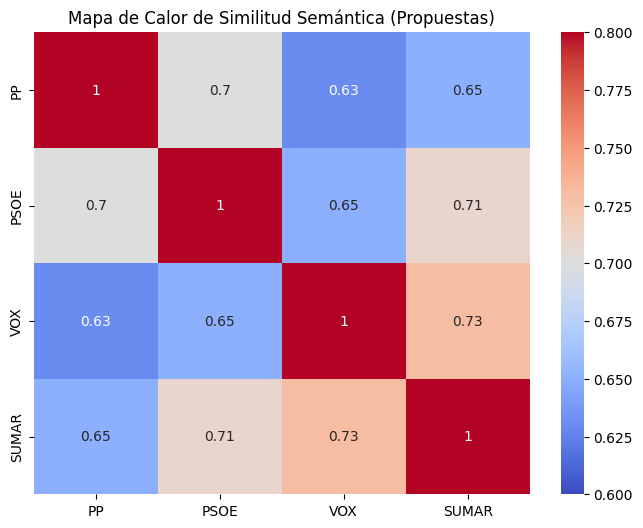

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creamos una matriz cuadrada con tus resultados (rellena los valores que obtuviste)
data = [[1.00, 0.70, 0.63, 0.65], 
        [0.70, 1.00, 0.65, 0.71],
        [0.63, 0.65, 1.00, 0.73],
        [0.65, 0.71, 0.73, 1.00]]

df_heatmap = pd.DataFrame(data, index=['PP', 'PSOE', 'VOX', 'SUMAR'], columns=['PP', 'PSOE', 'VOX', 'SUMAR'])

plt.figure(figsize=(8, 6))
sns.heatmap(df_heatmap, annot=True, cmap='coolwarm', vmin=0.6, vmax=0.8)
plt.title("Mapa de Calor de Similitud Semántica (Propuestas)")
plt.show()

In [ ]:
import re
import pandas as pd
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

def segmentar_en_propuestas(texto):
    # Patrón: busca párrafos que empiecen por números (1., 1.1) o guiones/bullets
    # O simplemente separa por bloques significativos de texto
    bloques = re.split(r'\n\s*\d+\.\s*|\n\s*-\s*', texto)
    # Filtramos bloques demasiado cortos o que no tengan contenido sustancial
    return [b.strip() for b in bloques if len(b.split()) > 10]

# 1. Función de extracción que devuelve el texto tal cual (sin lematizar)
def extraer_texto_puro(ruta):
    texto_total = ""
    with pdfplumber.open(ruta) as pdf:
        for pagina in pdf.pages:
            texto = pagina.extract_text()
            if texto:
                texto_total += texto + "\n"
    return texto_total

# 2. Bucle de procesamiento corregido
corpus_procesado = {}

for partido, ruta in programas.items():
    if os.path.exists(ruta):
        print(f"Procesando el programa de {partido}...")
        # EXTRACCIÓN DEL TEXTO
        texto_original = extraer_texto_puro(ruta)
        
        # Guardamos el texto original con frases completas
        corpus_procesado[partido] = texto_original 
        
        print(f"✓ {partido} procesado. Tamaño: {len(texto_original.split())} palabras.")
    else:
        print(f"Archivo no encontrado: {ruta}")
# Creamos un DataFrame para organizar los datos
data = []
for partido, texto in corpus_procesado.items():
    propuestas = segmentar_en_propuestas(texto)
    for p in propuestas:
        data.append({'partido': partido, 'propuesta': p})

df_propuestas = pd.DataFrame(data)

Procesando el programa de PP...
✓ PP procesado. Tamaño: 30891 palabras.
Procesando el programa de PSOE...
✓ PSOE procesado. Tamaño: 105894 palabras.
Procesando el programa de VOX...
✓ VOX procesado. Tamaño: 29151 palabras.
Procesando el programa de SUMAR...
✓ SUMAR procesado. Tamaño: 105529 palabras.


In [ ]:
# Convertimos cada propuesta en un vector
df_propuestas['vector'] = df_propuestas['propuesta'].apply(lambda x: model.encode(x))

#VECTORIZACIÓN DEL DATASET
print(df_propuestas.head())

  partido                                          propuesta  \
0      PP  PROGRAMA ELECTORAL\nun proyecto al servicio\nd...   
1      PP  Impulsar una economía basada en el la conviven...   
2      PP  Crear empleo de calidad para todos ..............   
3      PP  Aprovechar las posibilidades de 5. Lograr un b...   
4      PP  Controlar el déficit y la deuda 6. Reforzar la...   

                                              vector  
0  [-0.12938197, 0.03534005, -0.03672311, -0.0579...  
1  [-0.04787464, -0.021858351, -0.02508821, -0.05...  
2  [0.013808242, 0.17636889, -0.15122083, -0.1623...  
3  [-0.2002051, -0.31833187, 0.025872279, -0.4464...  
4  [-0.07117852, 0.18991698, -0.032289576, 0.0941...  


In [ ]:
def buscar_coincidencias(query, top_n=5):
    query_vec = model.encode(query)
    # Calculamos la similitud de la query contra todas las propuestas del dataset
    from sklearn.metrics.pairwise import cosine_similarity
    
    df_propuestas['similitud'] = df_propuestas['vector'].apply(lambda x: cosine_similarity([query_vec], [x])[0][0])
    
    return df_propuestas.sort_values(by='similitud', ascending=False).head(top_n)

# EJEMPLO
resultados = buscar_coincidencias("Reducción del IVA en la vivienda y acceso para jóvenes")
print(resultados[['partido', 'propuesta', 'similitud']])

    partido                                          propuesta  similitud
201     VOX  IVA: bajaremos radicalmente el IVA en los prod...   0.673948
209     VOX  A su vez, aplicaremos una reducción progresiva...   0.574278
418     VOX  Reduciremos radicalmente el IVA de los product...   0.572351
699   SUMAR  Acceso universal a la energía en un sistema ta...   0.567676
113     VOX  Impulsaremos la construcción viviendas sociale...   0.554402


In [50]:
import re
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Cargar modelo semántico
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# 2. Segmentación avanzada de propuestas
def segmentar_en_propuestas(texto):
    # Divide el texto basándose en puntos y aparte seguidos de números o guiones
    # Ajusta el patrón si tus PDFs tienen una estructura de títulos diferente
    bloques = re.split(r'\n(?=\d+\.)|\n(?=- )', texto)
    return [b.strip() for b in bloques if len(b.split()) > 10]

# 3. Crear el Dataset de Propuestas
data_propuestas = []
for partido, texto in corpus_procesado.items():
    lista_propuestas = segmentar_en_propuestas(texto)
    for p in lista_propuestas:
        data_propuestas.append({'partido': partido, 'propuesta': p})

df_propuestas = pd.DataFrame(data_propuestas)

def limpiar_texto(texto):
    # Eliminar URLs
    texto = re.sub(r'http\S+', '', texto)
    # Eliminar palabras que parecen basura de escaneo (palabras cortas, caracteres extraños)
    texto = re.sub(r'\b\w{1,3}\b', '', texto) 
    # Eliminar caracteres no alfanuméricos
    texto = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚ\s]', '', texto)
    return " ".join(texto.split())

# Aplica esto antes de generar el dataset
df_propuestas['propuesta_limpia'] = df_propuestas['propuesta'].apply(limpiar_texto)
# Ahora vectoriza 'propuesta_limpia' en lugar de 'propuesta'

# 4. Vectorización de cada propuesta (Generamos el 'ADN' de cada medida)
df_propuestas['vector'] = df_propuestas['propuesta'].apply(lambda x: model.encode(x))

# 5. Función de Búsqueda Semántica
def buscar_convergencia(tema_query, top_n=5):
    # Aseguramos que la query sea 2D (1, 384)
    query_vec = model.encode(tema_query).reshape(1, -1)
    
    # Calcular similitud
    # x es el vector que ya está en el dataframe. Lo convertimos a numpy array y lo reshapeamos a 2D
    def calcular_similitud(x):
        vec = np.array(x).reshape(1, -1)
        return cosine_similarity(query_vec, vec)[0][0]
    
    df_propuestas['similitud'] = df_propuestas['vector'].apply(calcular_similitud)
    
    return df_propuestas.sort_values(by='similitud', ascending=False).head(top_n)

# --- PRUEBA DEL ANÁLISIS MICRO ---
# Busca qué propone cada partido sobre un tema específico
tema = "aumentar el salario mínimo"
print(f"\nResultados de convergencia para: '{tema}'")
print(buscar_convergencia(tema)[['partido', 'propuesta', 'similitud']])


Resultados de convergencia para: 'aumentar el salario mínimo'
    partido                                          propuesta  similitud
473   SUMAR  5. Subiremos el salario mínimo interprofesiona...   0.684929
613   SUMAR  57. Estableceremos incentivos a la calidad en ...   0.631538
585   SUMAR  29. Pondremos fin a la precariedad en el contr...   0.627094
599   SUMAR  43. Apoyaremos a las personas trabajadoras aut...   0.601085
194     VOX  22.000€ anuales de rentas del trabajo con inde...   0.590555


In [56]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

def matriz_similitud_tematica(df, tema, model):
    # 1. Obtenemos el vector representativo del tema
    query_vec = model.encode(tema).reshape(1, -1)
    
    # 2. Calculamos relevancia de cada propuesta respecto al tema
    # Esto filtra las propuestas para quedarnos solo con las que hablan de ese tema
    def calcular_relevancia(x):
        return cosine_similarity(query_vec, x.reshape(1, -1))[0][0]
    
    df['relevancia'] = df['vector'].apply(calcular_relevancia)
    
    # 3. Nos quedamos con las propuestas que tienen una carga temática alta (> 0.2)
    df_filtrado = df[df['relevancia'] > 0.2].copy()
    
    # 4. Agrupamos por partido y calculamos el "centroide" (el vector medio) de sus propuestas sobre ese tema
    partidos = df['partido'].unique()
    centroides = {}
    for p in partidos:
        props_partido = df_filtrado[df_filtrado['partido'] == p]
        if not props_partido.empty:
            # Promedio de los vectores de las propuestas del partido sobre el tema
            centroides[p] = np.stack(props_partido['vector'].values).mean(axis=0)
    
    # 5. Creamos la matriz comparativa
    lista_partidos = list(centroides.keys())
    matriz = pd.DataFrame(index=lista_partidos, columns=lista_partidos)
    
    for i in lista_partidos:
        for j in lista_partidos:
            sim = cosine_similarity(centroides[i].reshape(1, -1), centroides[j].reshape(1, -1))
            matriz.loc[i, j] = sim[0][0]
            
    return matriz

# --- EJECUCIÓN ---
# Puedes cambiar el tema por: "vivienda", "empleo", "sanidad", "impuestos", "educación"
tema_elegido = "Sanidad"
matriz = matriz_similitud_tematica(df_propuestas, tema_elegido, model)

print(f"\n--- Matriz de Similitud en el tema: {tema_elegido} ---")
print(matriz)


--- Matriz de Similitud en el tema: Sanidad ---
             PP      PSOE       VOX     SUMAR
PP          1.0  0.715743  0.798227   0.80971
PSOE   0.715743       1.0  0.821813  0.904223
VOX    0.798227  0.821813       1.0  0.899237
SUMAR   0.80971  0.904223  0.899237       1.0


In [52]:
print(df_propuestas.groupby('partido').size())

partido
PP        22
PSOE      19
SUMAR    787
VOX      409
dtype: int64


In [58]:
# Definimos el tamaño mínimo disponible
n_minimo = df_propuestas.groupby('partido').size().min()

# Usamos ese mínimo para equilibrar todos los partidos
df_equilibrado = df_propuestas.groupby('partido').sample(n=n_minimo, random_state=42)

# Ahora ejecutamos la matriz
matriz_final = matriz_similitud_tematica(df_equilibrado, "Educación", model)
print(matriz_final)

             PP      PSOE     SUMAR       VOX
PP          1.0  0.725021  0.741806  0.652931
PSOE   0.725021       1.0  0.807322   0.77069
SUMAR  0.741806  0.807322       1.0  0.691892
VOX    0.652931   0.77069  0.691892       1.0


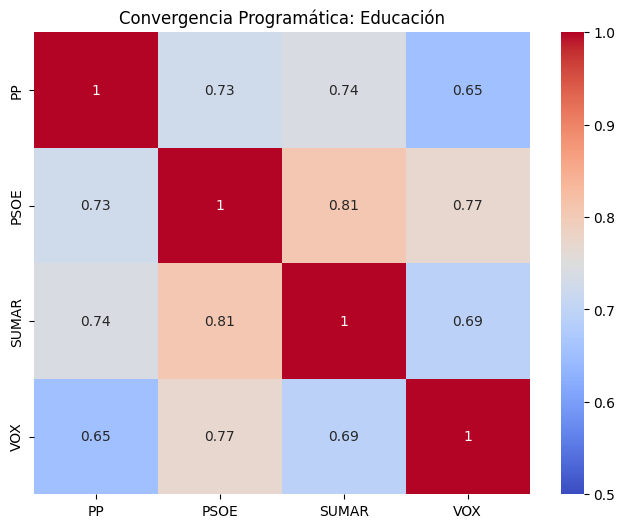

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_final.astype(float), annot=True, cmap='coolwarm', vmin=0.5, vmax=1.0)
plt.title("Convergencia Programática: Educación")
plt.show()